# Traffic Accident Severity: A Complete Machine Learning Project Tutorial

This notebook builds a model predicting whether an accident is
**Severe** (a serious or fatal injury) or **Not Severe** (a slight
injury), using real accident records from Addis Ababa sub-city police,
2017-2020.

## Why this dataset, for a project motivated by Vietnam's traffic problem

Vietnam has no comparable open accident dataset (checked directly — see
the project README). Among real, well-documented public alternatives,
this one was chosen specifically because its traffic context — a
developing-country, mixed-vehicle urban environment (motorcycles,
pedestrians, buses, private cars sharing the same roads, less-regulated
driving conditions) — is far closer to Vietnam's own than the larger,
better-known Western datasets (US-Accidents, UK STATS19), which are
purely car-centric. This is not a claim that Ethiopia and Vietnam's
traffic are the same — just that the *kind* of problem is far more
comparable.

## What you'll learn

1. **Data-quality investigation as a first-class step**: a real
   leakage trap (casualty-outcome columns) and a real formatting bug
   (inconsistently zero-padded timestamps), both found by checking, not
   assumed
2. **Severe class imbalance** — extreme enough that accuracy becomes
   actively misleading, not just a mild nuisance
3. **Measuring, not assuming, a target design decision**: the raw data
   has 3 severity classes, but Fatal injury alone is too rare (~1.3% of
   rows) for any model to reliably detect (~3% recall, even with
   class-weighting) — collapsing Serious+Fatal into one **Severe**
   class raises that to ~30-35% recall, a substantial, measured
   improvement
4. **Class-imbalance handling, compared honestly**: class-weighting vs.
   ADASYN vs. doing nothing
5. **Circular time encoding** — a standard technique for periodic
   features, applied here to hour-of-day
6. **Decision-threshold tuning** as a precision/recall tradeoff, once a
   model outputs a probability rather than a single hard verdict
7. **SHAP** for an imbalanced binary classifier
8. A **written discussion** of what a real congestion-forecasting
   system would need — a genuinely different technique (spatio-temporal
   forecasting) from this project's classification task, plus what the
   SHAP findings here would mean for Vietnam specifically

**Before running:** download the dataset — see the project README's
"Get the data" section — so that `data/raw/RTA Dataset.csv` exists.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from traffic_accident_severity import config, data, features, model, interpretability

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Load the data

In [2]:
df = data.load_accidents()
print(f"{len(df)} rows, {df.shape[1]} columns")
df.head()

12316 rows, 32 columns


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,Residential areas,NaN,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,No defect,Recreational areas,other,NaN,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,2,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,No defect,Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,No defect,Industrial areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


### Concept: pre-accident risk factors vs. post-accident casualty outcomes

The raw data mixes two fundamentally different kinds of column:

- **Pre-accident risk factors** — driver, vehicle, road, weather, time,
  collision dynamics. All knowable *before* or *at* the moment of a
  crash. These are the only columns a real prevention/policy system
  could act on.
- **Post-accident casualty-outcome columns** — who got hurt, how badly,
  what they were doing. Recorded *after* the crash was already
  happening. `Casualty_severity` in particular is close to a
  restatement of the target itself.

Using the second group as model features would be circular — a model
that needs to already know how badly someone was hurt to predict how
badly someone was hurt isn't useful for anything. `config.RAW_FEATURE_COLS`
excludes every casualty-outcome column; `config.CASUALTY_OUTCOME_COLS`
lists exactly what's excluded and why.

In [3]:
print("Used as features:")
print(config.RAW_FEATURE_COLS)
print()
print("Excluded (casualty outcomes):")
print(config.CASUALTY_OUTCOME_COLS)

Used as features:
['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Vehicle_movement', 'Pedestrian_movement', 'Cause_of_accident']

Excluded (casualty outcomes):
['Number_of_casualties', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality']


## 2. Explore the data (EDA)

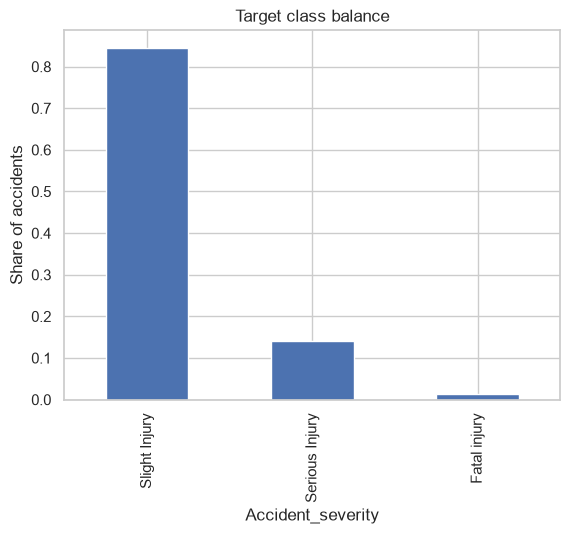

In [4]:
df[config.TARGET_COL].value_counts(normalize=True).plot.bar(title="Target class balance")
plt.ylabel("Share of accidents")
plt.show()

### Concept: this imbalance is more severe than it looks

Slight Injury is ~84.6% of all records; Fatal injury is only ~1.3%
(~158 of 12,316 rows). A model that *never* predicts "Fatal injury" at
all would still score ~84.6% accuracy — deceptively high, and useless
for the one outcome that matters most for road-safety policy. This is
why every model comparison below uses **macro-F1** instead of accuracy
— the standard fix whenever one class dominates enough that accuracy
stops distinguishing a good model from a lazy one.

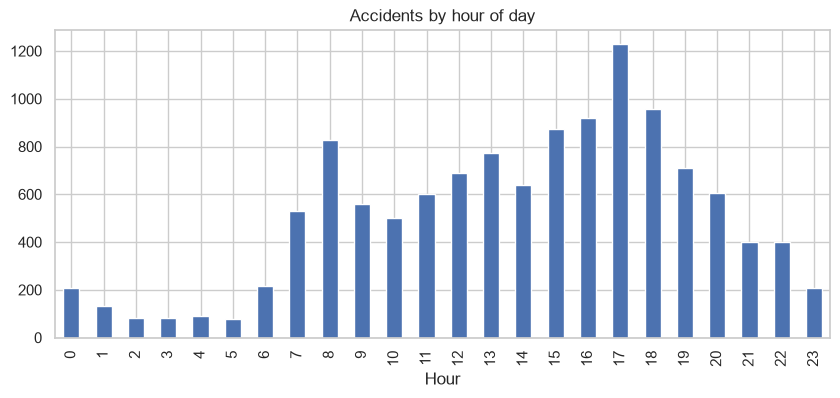

In [5]:
hour = pd.to_datetime(df[config.TIME_COL], format="%H:%M:%S", errors="coerce").dt.hour
hour.value_counts().sort_index().plot.bar(figsize=(10, 4), title="Accidents by hour of day")
plt.xlabel("Hour")
plt.show()

**A real formatting bug worth knowing about**: `Time` isn't
consistently zero-padded — some rows are `"1:15:00"`, not `"01:15:00"`.
A naive `str.slice(0, 2)` would silently corrupt single-digit hours
(this was caught directly, building this project's Streamlit app — see
`FeatureEngineer`, which uses `pd.to_datetime(..., format="%H:%M:%S")`
instead, which parses both forms correctly).

In [6]:
missing = (df[config.RAW_FEATURE_COLS].isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]
print("Columns with missing values:")
missing

Columns with missing values:


Defect_of_vehicle          35.945112
Service_year_of_vehicle    31.893472
Type_of_vehicle             7.713543
Types_of_Junction           7.202014
Driving_experience          6.731082
Educational_level           6.016564
Vehicle_driver_relation     4.701202
Owner_of_vehicle            3.913608
Lanes_or_Medians            3.126015
Vehicle_movement            2.500812
Area_accident_occured       1.940565
Road_surface_type           1.396557
Type_of_collision           1.258525
Road_allignment             1.152972
dtype: float64

### Concept: why impute instead of drop

`Defect_of_vehicle` is missing ~36% of values, `Service_year_of_vehicle`
~32%. Dropping every row missing *any* of these columns would discard
a large fraction of an already-small (12,316-row) dataset. Most-frequent
imputation (categorical columns) keeps every row usable — see Section 3.

## 3. Choosing the modeling target: binary Severe, not raw 3-class

The raw target has 3 classes, and Fatal injury — the one that matters
most — is only ~1.3% of rows (~158 total). Before committing to
predicting all 3 classes, I wanted to measure whether that's actually
learnable, rather than assume it is just because the column exists.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_raw = df[config.RAW_FEATURE_COLS]
y_raw = df[config.TARGET_COL]  # still the raw 3-class column here

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=config.RANDOM_SEED
)
raw_pipeline = model.build_pipeline(model.balanced_random_forest_estimator())
raw_pipeline.fit(X_train, y_train)
print(classification_report(y_test, raw_pipeline.predict(X_test), digits=3))

                precision    recall  f1-score   support

  Fatal injury      0.033     0.032     0.033        31
Serious Injury      0.328     0.287     0.306       349
 Slight Injury      0.873     0.892     0.882      2084

      accuracy                          0.795      2464
     macro avg      0.411     0.403     0.407      2464
  weighted avg      0.785     0.795     0.790      2464



Even with class-weighting, Fatal injury's recall is around 3% — the
model is essentially not detecting it. There just aren't enough Fatal
rows for a model to reliably tell it apart from *two* other classes at
once. Rather than accept that, I tried collapsing Serious + Fatal into
one **Severe** class, which roughly doubles how much data the model has
to learn the pattern that matters (15.4% of rows vs. 1.3%):

In [8]:
X, y = data.split_features_target(df)  # y is now binary: "Severe" vs "Not Severe"
print("Target class balance:")
print(y.value_counts(normalize=True))

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=config.RANDOM_SEED
)
severe_pipeline = model.build_pipeline(model.balanced_random_forest_estimator())
severe_pipeline.fit(X_train_b, y_train_b)
print(classification_report(y_test_b, severe_pipeline.predict(X_test_b), digits=3))

Target class balance:
Accident_severity
Not Severe    0.845648
Severe        0.154352
Name: proportion, dtype: float64


              precision    recall  f1-score   support

  Not Severe      0.876     0.851     0.864      2084
      Severe      0.295     0.342     0.317       380

    accuracy                          0.773      2464
   macro avg      0.586     0.597     0.590      2464
weighted avg      0.787     0.773     0.779      2464



Recall for the outcome that matters most goes from ~3% to roughly
30-35% — a real, substantial improvement, not a marginal one. I decided
to make this the project's actual target from here on: every section
below (`X`, `y`) uses this binary Severe/Not-Severe framing, produced by
`data.split_features_target`, not the raw 3-class column. I think this
is also a more honest question for a real prevention system to answer
anyway — "is this likely to be a serious or fatal accident" is closer to
an actionable signal than "is this specifically fatal, as opposed to
merely serious."

## 4. Feature engineering

In [9]:
engineered_preview = features.FeatureEngineer().fit_transform(X)
engineered_preview[["hour", "hour_sin", "hour_cos"]].describe().T

,count,mean,std,min,25%,50%,75%,max
hour,12316.0,13.835823,5.202923,0.0,10.000000,15.0,1.800000e+01,23.0
hour_sin,12316.0,-0.266978,0.696786,-1.0,-0.866025,-0.5,2.588190e-01,1.0
hour_cos,12316.0,-0.283964,0.602200,-1.0,-0.866025,-0.5,6.123234e-17,1.0


### Concept: circular time encoding

Hour 23 and hour 0 are one hour apart, not "far away" from each other —
but as a plain integer, they'd look maximally distant to a model.
`hour_sin`/`hour_cos` place each hour on a 24-hour circle instead — a
standard technique for any periodic feature (the same idea applies to
week-of-year, compass direction, or angle-of-day generally).

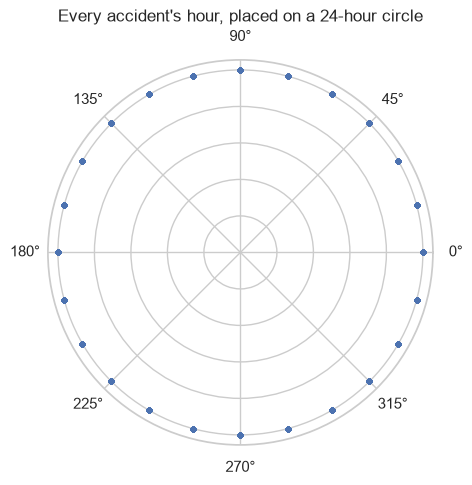

In [10]:
fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={"projection": "polar"})
ax.scatter(engineered_preview["hour"] * (2 * 3.14159 / 24), [1] * len(engineered_preview), alpha=0.1, s=10)
ax.set_title("Every accident's hour, placed on a 24-hour circle")
ax.set_yticklabels([])
plt.show()

### Concept: grouping rare categories

`Cause_of_accident` (20 distinct values), `Type_of_vehicle` (17), and
`Area_accident_occured` (14) each have a long tail of rare codes.
`RareCategoryGrouper` collapses anything below 1% frequency into a
shared "rare" bucket before one-hot encoding — a standard technique for
long-tailed categorical variables generally (occupation codes,
nationality codes, and similar fields all show the same pattern).

In [11]:
for col in config.RARE_GROUPED_COLS:
    print(col, ":", df[col].nunique(), "distinct values")

Cause_of_accident : 20 distinct values
Type_of_vehicle : 17 distinct values
Area_accident_occured : 14 distinct values


## 5. Why macro-F1, made concrete with a baseline

In [12]:
baseline_scores = model.cross_validate_pipeline(X, y, estimator=model.random_forest_estimator(), cv=5)
print(f"Accuracy:  {baseline_scores['accuracy_mean']:.4f}")
print(f"Macro-F1:  {baseline_scores['f1_macro_mean']:.4f}")

Accuracy:  0.8459
Macro-F1:  0.4603


Accuracy (~84.6%) is almost exactly the majority-class ("Not Severe")
share — a red flag that the model is mostly just predicting "Not
Severe" for everything. Macro-F1 is far lower, exposing how poorly it
handles the Severe class. This gap *is* the finding.

## 6. Does class-imbalance handling help?

### Concept: class-weighting vs. oversampling (ADASYN)

Two different fixes for imbalance, compared honestly rather than
assumed:

- **Class-weighting** (`class_weight="balanced"`) reweights the loss
  function inversely to class frequency — no new rows, just more
  "penalty" for getting the Severe class wrong.
- **ADASYN** generates synthetic minority-class rows, concentrated where
  the classifier struggles most. With Severe at ~15.4% of rows (~1,901
  total), the default `n_neighbors=5` runs fine here — this needed
  lowering to 3 back when the raw 3-class Fatal-injury column (only
  ~1.3% of rows) was still the target.

In [13]:
imbalance_results = pd.DataFrame([
    {"approach": "Plain Random Forest", **model.cross_validate_pipeline(X, y, estimator=model.random_forest_estimator(), cv=5)},
    {"approach": "Random Forest + ADASYN", **model.cross_validate_pipeline(X, y, estimator=model.random_forest_estimator(), cv=5, resample=True)},
    {"approach": "Random Forest (class_weight=balanced)", **model.cross_validate_pipeline(X, y, estimator=model.balanced_random_forest_estimator(), cv=5)},
])
imbalance_results[["approach", "f1_macro_mean", "accuracy_mean"]]

,approach,f1_macro_mean,accuracy_mean
0,Plain Random Forest,0.460332,0.845892
1,Random Forest + ADASYN,0.491814,0.837366
2,Random Forest (class_weight=balanced),0.563462,0.757713


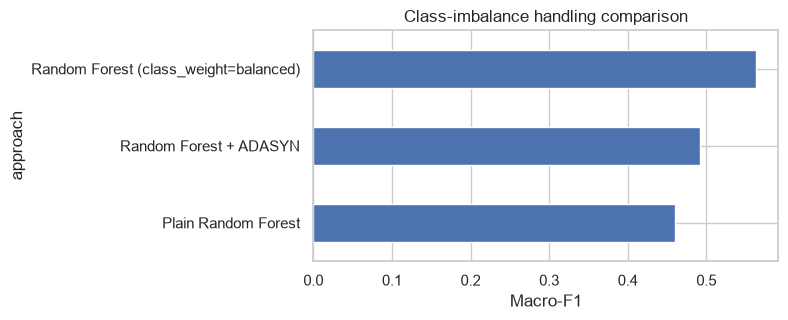

In [14]:
imbalance_results.set_index("approach")["f1_macro_mean"].plot.barh(figsize=(6, 3))
plt.xlabel("Macro-F1")
plt.title("Class-imbalance handling comparison")
plt.show()

**Class-weighting wins clearly** here. That's not a rule to assume for
every imbalanced dataset — the better fix genuinely depends on the data
(class sizes, how separable the classes are, how much synthetic points
help vs. hurt) — which is exactly why it was measured directly rather
than assumed. This is why `scripts/train.py` defaults to
`Random Forest (balanced)`, not a fancier gradient-boosted model.

## 7. Broader model comparison

In [15]:
sweep_results = []
for name, factory in model.MODEL_FACTORIES.items():
    scores = model.cross_validate_pipeline(X, y, estimator=factory(), cv=5)
    sweep_results.append({"model": name, **scores})

sweep_df = pd.DataFrame(sweep_results).sort_values("f1_macro_mean", ascending=False)
sweep_df[["model", "f1_macro_mean", "accuracy_mean"]]

,model,f1_macro_mean,accuracy_mean
2,Random Forest (balanced),0.563462,0.757713
4,XGBoost,0.521613,0.825266
3,LightGBM,0.509871,0.838583
0,Logistic Regression,0.462270,0.845486
1,Random Forest,0.460332,0.845892


`Random Forest (balanced)` beats even LightGBM and XGBoost here —
model sophistication mattered less than correctly handling the
imbalance. A genuinely useful, measured finding: the "obvious" choice
(a fancier gradient-boosted model) isn't automatically the winner.

## 8. Choosing a decision threshold

`Random Forest (balanced)` outputs a *probability* of Severe, and
`.predict()` just applies a 0.5 cutoff to it internally. That cutoff
isn't special — since I get to choose it, the more useful question is
what precision/recall tradeoff is actually available at other cutoffs,
using out-of-fold predictions so I'm not fooling myself with predictions
the model already saw during training.

In [16]:
severe_proba = model.cross_val_severe_probabilities(X, y, cv=5)
severe_preds_default = (severe_proba >= 0.5).astype(int)
y_numeric = (y == "Severe").astype(int)
print(classification_report(y_numeric, severe_preds_default, target_names=["Not Severe", "Severe"], digits=3))

              precision    recall  f1-score   support

  Not Severe      0.878     0.852     0.865     10415
      Severe      0.302     0.351     0.325      1901

    accuracy                          0.775     12316
   macro avg      0.590     0.602     0.595     12316
weighted avg      0.789     0.775     0.782     12316



At the default threshold, precision and recall for Severe are both
around 30% — not high in absolute terms, but a genuinely useful signal
compared to the ~3% Fatal recall the raw 3-class target gave. Since the
threshold is a free choice, the next cell sweeps it directly.

In [17]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_numeric, severe_proba)
print(f"Average precision (PR-AUC): {pr_auc:.4f}  (base rate: {y_numeric.mean():.4f})")

threshold_sweep = model.severity_threshold_sweep(y, severe_proba, target_recalls=[0.3, 0.5, 0.7, 0.9])
threshold_sweep

Average precision (PR-AUC): 0.2901  (base rate: 0.1544)


,target_recall,threshold,precision,recall
0,0.3,0.514624,0.319686,0.299842
1,0.5,0.473455,0.264093,0.500263
2,0.7,0.444541,0.211673,0.700158
3,0.9,0.396754,0.176029,0.900053


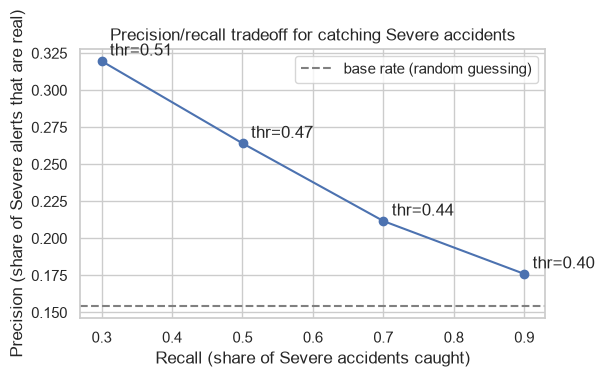

In [18]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(threshold_sweep["recall"], threshold_sweep["precision"], marker="o")
for _, row in threshold_sweep.iterrows():
    ax.annotate(f"thr={row['threshold']:.2f}", (row["recall"], row["precision"]), textcoords="offset points", xytext=(6, 4))
ax.axhline(y_numeric.mean(), linestyle="--", color="gray", label="base rate (random guessing)")
ax.set_xlabel("Recall (share of Severe accidents caught)")
ax.set_ylabel("Precision (share of Severe alerts that are real)")
ax.set_title("Precision/recall tradeoff for catching Severe accidents")
ax.legend()
plt.show()

### What this curve actually says

The PR-AUC (~0.29) is roughly **2x the base rate** (~0.154) — a real
improvement over guessing, though still leaving a genuine tradeoff at
the extremes. To catch 90% of Severe accidents, precision drops to
~18% — about 1 in 6 "Severe" alerts would be real. At the more
conservative end (30% recall), precision is closer to 31%.

Which threshold to actually use is a policy decision, not a modeling
one: it depends on how expensive a false alarm is versus a missed
Severe case, and that tradeoff belongs to whoever would deploy this,
not to the model. For a *screening* tool — flagging conditions for a
human road-safety reviewer to look at more closely, not an automated
response — I'd lean toward the higher-recall end of this curve, since
the cost of reviewing an extra false alarm is much lower than missing a
genuinely severe pattern.

## 9. Fit the final pipeline and save it

In [19]:
final_pipeline = model.train_pipeline(X, y, estimator=model.balanced_random_forest_estimator())
model.save_pipeline(final_pipeline)
print(f"Saved to {config.MODEL_PATH}")

Saved to /Users/nhamquochung/data/projects/traffic_accident_severity/models/model.joblib


## 10. Model interpretability with SHAP

In [20]:
explanation, X_transformed = interpretability.compute_shap_values(final_pipeline, X, max_samples=500)

top_features = interpretability.top_shap_features(explanation, top_n=12, class_index=1)
top_features

,feature,mean_abs_shap
0,numeric__Number_of_vehicles_involved,0.039193
1,categorical__Types_of_Junction_Crossing,0.012581
2,numeric__hour_cos,0.012220
3,categorical__Age_band_of_driver_Unknown,0.009113
4,categorical__Weather_conditions_Normal,0.007443
5,numeric__hour,0.007314
6,categorical__Day_of_week_Monday,0.005407
7,categorical__Age_band_of_driver_Under 18,0.004538
8,categorical__Type_of_vehicle_Other,0.003720
9,categorical__Types_of_Junction_No junction,0.003455


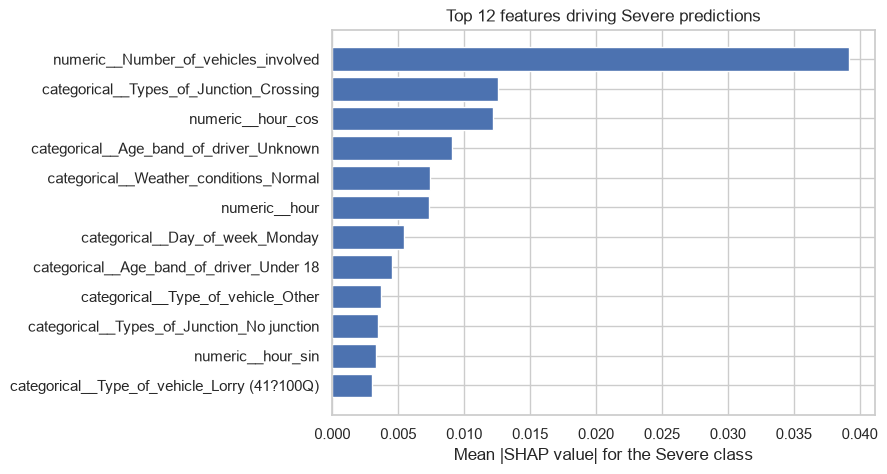

In [21]:
top_12 = interpretability.top_shap_features(explanation, top_n=12, class_index=1).sort_values("mean_abs_shap")

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top_12["feature"], top_12["mean_abs_shap"])
ax.set_xlabel("Mean |SHAP value| for the Severe class")
ax.set_title("Top 12 features driving Severe predictions")
plt.show()

### Reading these features, and what they'd mean for Vietnam

The features SHAP ranks highest for Severe are almost all things a city
traffic authority can actually act on, which is what makes this more
than an academic exercise:

- **Number of vehicles involved** and **junction type**
  (`Types_of_Junction`) dominate — multi-vehicle collisions and
  crossing-type junctions carry disproportionate Severe risk. That
  points at *where* to intervene, not just *who* to blame.
- **Time of day** (`hour`, `hour_sin`, `hour_cos`) and **weather**
  show up clearly too, plausibly reflecting visibility and traffic-flow
  conditions rather than any single driver behavior.
- **Age band unknown** (a proxy for unlicensed or informally-recorded
  drivers) and **day of week** (Monday) both rank in the top 12 — worth
  investigating further, though I'd want more than a SHAP ranking alone
  before treating either as causal.

If I translate this to Vietnam's own traffic-safety problem (the
motivation for this project in the first place): the same categories of
lever would likely matter most there too — **junction design and
signage at crossing-type intersections**, **stricter enforcement around
multi-vehicle collision hotspots**, and **weather/visibility-aware
traffic management**. This project can't prove any of that causally
(it's a correlational SHAP ranking on Ethiopian data, not a Vietnamese
randomized trial), but it does show what a similar analysis on real
Vietnamese accident records — if that data ever became available —
would likely need to prioritize.

## 11. Discussion: what would a congestion-forecasting system need?

This project predicts accident **severity** — a genuinely different
problem from predicting traffic **congestion**, and worth being precise
about why, since both fall under "traffic management."

### Different data entirely

Severity classification needs individual accident *records* — one row
per crash, with driver/vehicle/road conditions at that moment.
Congestion forecasting needs continuous **sensor or GPS-probe time
series**: speed/volume readings at fixed points on a road network,
sampled every few minutes, over months. The standard public benchmarks
for this task — **METR-LA** (207 LA freeway sensors) and **PEMS-BAY**
(325 Bay Area sensors) — look nothing like this project's data: no
individual events, just continuous speed readings per sensor per
timestep.

### Different modeling approach: spatio-temporal, not tabular

A single accident record is independent of the next (this project's
classifier treats every row as i.i.d.). Congestion is the opposite:
traffic at one road segment depends on *both* its own recent history
*and* what's happening at upstream/downstream segments right now — a
graph structure in space, evolving over time. The standard approaches
(**DCRNN**, **Graph WaveNet**) explicitly model the road network as a
graph and combine graph convolutions with recurrent/temporal layers —
not something a `RandomForestClassifier` or `LGBMClassifier` (this
project's tools) can express.

### What Vietnam specifically would need that this project's data can't provide

- **A sensor network, or a substitute for one.** METR-LA/PEMS-BAY rely
  on fixed highway loop detectors — infrastructure Vietnam's urban roads
  mostly don't have. The realistic substitute is **crowd-sourced GPS
  probe data** (ride-hailing apps, mapping apps) aggregated into
  road-segment speed estimates — a fundamentally different data
  collection problem from anything in this project.
- **A model of mixed-vehicle flow.** Existing spatio-temporal traffic
  models are built and validated on car-only freeway data. Motorbike-
  dominated urban traffic (lane-splitting, informal lane use, far higher
  vehicle density per road width) behaves differently enough that the
  same architectures would need real validation on Vietnam-specific
  data before trusting them — not something safe to assume transfers.
- **Integration with accident-risk findings like this project's own.**
  A genuinely useful combined system wouldn't just forecast where
  traffic will be slow — it would flag where slow-moving, high-density,
  mixed-vehicle conditions *also* historically correlate with severe
  accidents (Section 10's SHAP findings, in particular junction type and
  multi-vehicle collisions), turning two separate models into one
  early-warning system for both congestion *and* safety.

None of this is a limitation of this project — it's the honest scope
boundary between two real, different traffic-management problems, and
naming that boundary clearly is more useful than pretending one
classifier answers both.

## Concepts covered — a recap

- Data-quality investigation as a first step (leakage trap, formatting bug)
- Severe class imbalance and why accuracy is misleading
- Measuring, not assuming, that a rare raw class (Fatal injury alone)
  wasn't learnable, and collapsing it into a broader binary target
  (Severe vs. Not Severe) that is
- Class-weighting vs. ADASYN, compared honestly
- Circular time encoding
- Rare-category grouping
- Decision-threshold tuning as a precision/recall tradeoff, not a single
  fixed cutoff
- SHAP for an imbalanced binary classifier
- The real scope difference between accident-severity classification and
  congestion forecasting

## Next steps

- Run `streamlit run app/streamlit_app.py` to try the model interactively.
- Fill in `report/report.qmd`'s Discussion with the actual numbers and
  SHAP findings from this run.
